# NB_05 · Évaluation des modèles

### Prédiction des annulations de réservations hôtelières

## Objectif du notebook

Ce notebook est consacré à l'évaluation des 8 modèles entraînés dans le Notebook 04, à l'aide de plusieurs métriques complémentaires calculées sur le jeu de test.

L'objectif est de comparer objectivement les performances des modèles entraînés sur la version originale des données et sur la version réduite par PCA, de sélectionner le modèle final le plus adapté à l'objectif métier, et de trancher la décision méthodologique concernant l'utilité réelle de la PCA pour ce projet.

Les analyses portent notamment sur :

- le calcul des métriques de classification (Accuracy, Precision, Recall, F1-score, ROC-AUC) ;
- la comparaison directe entre les versions Original et PCA, globalement et par algorithme ;
- les matrices de confusion et les courbes ROC ;
- la sélection du modèle final ;
- l'importance des variables du modèle retenu.


# 1. Chargement des données de test et des modèles

Les matrices de test et les 8 modèles sauvegardés dans le Notebook 04 sont chargés, à partir du manifeste d'entraînement.

In [1]:
from pathlib import Path
import json
import time
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay
)

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODEL_DIR = PROJECT_ROOT / "models"
METRIC_DIR = PROJECT_ROOT / "reports" / "metrics"
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
METRIC_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

X_test_original = sparse.load_npz(PROCESSED_DIR / "X_test.npz")
X_test_pca = sparse.load_npz(PROCESSED_DIR / "X_test_pca.npz")
y_test = pd.read_csv(PROCESSED_DIR / "y_test.csv")["is_canceled"]
manifest = pd.read_csv(MODEL_DIR / "model_manifest.csv")

print("Test original :", X_test_original.shape)
print("Test PCA      :", X_test_pca.shape)
print("Modèles dans le manifeste :", len(manifest))


Test original : (17446, 556)
Test PCA      : (17446, 9)
Modèles dans le manifeste : 8


### Interprétation

Le jeu de test comporte 17 446 réservations, cohérent avec le découpage 80/20 réalisé dans le Notebook 03. Les 8 modèles du manifeste sont retrouvés et prêts à être évalués.

### Décision

Chaque modèle sera évalué sur la version de données qui correspond à son entraînement (Original ou PCA), afin que la comparaison reste cohérente avec la façon dont chaque modèle a appris.

# 2. Calcul des métriques et du temps d'inférence

Cinq métriques sont calculées pour chaque modèle : Accuracy, Precision, Recall, F1-score et ROC-AUC. Le Recall de la classe « annulée » est particulièrement surveillé, car il mesure la capacité du modèle à détecter les réservations réellement à risque — l'objectif métier principal de ce projet.

In [2]:
results = []
predictions = {}
probabilities = {}
loaded_models = {}

for _, row in manifest.iterrows():
    name = row["Modèle"]
    version = row["Version_données"]
    X_eval = X_test_pca if version == "PCA" else X_test_original
    model = joblib.load(MODEL_DIR / row["Fichier"])
    loaded_models[name] = model

    start = time.perf_counter()
    y_pred = model.predict(X_eval)
    y_proba = model.predict_proba(X_eval)[:, 1]
    inference_time = time.perf_counter() - start

    predictions[name] = y_pred
    probabilities[name] = y_proba
    results.append({
        "Modèle": name,
        "Famille": row.get("Famille", name.replace(" - PCA", "")),
        "Version_données": version,
        "Nombre_variables": int(row["Nombre_variables"]),
        "Temps_entraînement_secondes": float(row["Temps_entraînement_secondes"]),
        "Temps_inférence_secondes": inference_time,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })

comparison = pd.DataFrame(results).sort_values(
    ["F1-score", "ROC-AUC"], ascending=False
).reset_index(drop=True)

comparison.to_csv(METRIC_DIR / "model_comparison.csv", index=False)
comparison.round(4)


,Modèle,Famille,Version_données,Nombre_variables,Temps_entraînement_secondes,Temps_inférence_secondes,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Random Forest,Random Forest,Original,556,2.6526,0.1047,0.7765,0.5620,0.8513,0.6770,0.8831
1,Logistic Regression,Logistic Regression,Original,556,1.6159,0.0066,0.8075,0.6926,0.5404,0.6071,0.8690
2,Random Forest - PCA,Random Forest,PCA,9,16.0309,0.1247,0.7920,0.6341,0.5777,0.6046,0.8190
3,Decision Tree - Entropy,Decision Tree - Entropy,Original,556,0.1355,0.0166,0.6561,0.4269,0.7278,0.5381,0.7088
4,Decision Tree - Gini,Decision Tree - Gini,Original,556,0.1191,0.0065,0.6587,0.4287,0.7220,0.5380,0.7089
5,Decision Tree - Entropy - PCA,Decision Tree - Entropy,PCA,9,0.4080,0.0025,0.6127,0.3793,0.6391,0.4760,0.6764
6,Decision Tree - Gini - PCA,Decision Tree - Gini,PCA,9,0.3246,0.0036,0.6209,0.3840,0.6245,0.4756,0.6753
7,Logistic Regression - PCA,Logistic Regression,PCA,9,0.0980,0.0013,0.7483,0.6444,0.1910,0.2946,0.7090


### Interprétation

Le classement par F1-score place le **Random Forest sur données originales** en tête (Accuracy 77,65 %, Recall 85,13 %, F1-score 0,677, ROC-AUC 0,883), suivi par la Logistic Regression originale (F1-score 0,607) puis le Random Forest PCA (F1-score 0,605). Les Decision Tree obtiennent des scores plus modestes (F1-score autour de 0,54), cohérent avec leur profondeur volontairement limitée à 3 niveaux. La Logistic Regression PCA obtient le résultat le plus faible (F1-score 0,295), la réduction à 9 composantes semblant particulièrement pénaliser un modèle linéaire.

### Décision

Le ROC-AUC est utilisé en complément du F1-score, car il mesure la capacité du modèle à bien classer quel que soit le seuil de décision choisi, contrairement à l'Accuracy qui peut être trompeuse sur un jeu de données au déséquilibre modéré. Ces deux métriques serviront de base à la sélection du modèle final (section 6).

# 3. Comparaison directe Original vs PCA

Cette section confronte les deux versions de données, d'abord de façon globale, puis par paire d'algorithmes identiques.

In [3]:
comparison_columns = [
    "Modèle", "Version_données", "Nombre_variables",
    "Temps_entraînement_secondes", "Temps_inférence_secondes",
    "Accuracy", "F1-score", "ROC-AUC"
]
comparison[comparison_columns].round(4)


,Modèle,Version_données,Nombre_variables,Temps_entraînement_secondes,Temps_inférence_secondes,Accuracy,F1-score,ROC-AUC
0,Random Forest,Original,556,2.6526,0.1047,0.7765,0.6770,0.8831
1,Logistic Regression,Original,556,1.6159,0.0066,0.8075,0.6071,0.8690
2,Random Forest - PCA,PCA,9,16.0309,0.1247,0.7920,0.6046,0.8190
3,Decision Tree - Entropy,Original,556,0.1355,0.0166,0.6561,0.5381,0.7088
4,Decision Tree - Gini,Original,556,0.1191,0.0065,0.6587,0.5380,0.7089
5,Decision Tree - Entropy - PCA,PCA,9,0.4080,0.0025,0.6127,0.4760,0.6764
6,Decision Tree - Gini - PCA,PCA,9,0.3246,0.0036,0.6209,0.4756,0.6753
7,Logistic Regression - PCA,PCA,9,0.0980,0.0013,0.7483,0.2946,0.7090


### Interprétation

Sur les 4 modèles PCA, aucun ne dépasse son équivalent entraîné sur les données originales, que ce soit en F1-score ou en ROC-AUC. La version PCA n'est pas non plus systématiquement plus rapide à l'entraînement, comme observé pour le Random Forest.

### Décision

Un simple classement global suggère déjà que la PCA n'apporte pas d'avantage net. La section suivante quantifie précisément cet écart, algorithme par algorithme.

In [4]:
original = comparison.query("Version_données == 'Original'").set_index("Famille")
pca_version = comparison.query("Version_données == 'PCA'").set_index("Famille")
common_families = original.index.intersection(pca_version.index)

paired_rows = []
for family in common_families:
    o = original.loc[family]
    p = pca_version.loc[family]
    paired_rows.append({
        "Famille": family,
        "Variables_originales": int(o["Nombre_variables"]),
        "Composantes_PCA": int(p["Nombre_variables"]),
        "Réduction_%": 100 * (1 - p["Nombre_variables"] / o["Nombre_variables"]),
        "Temps_train_original_s": o["Temps_entraînement_secondes"],
        "Temps_train_PCA_s": p["Temps_entraînement_secondes"],
        "Delta_Recall": p["Recall"] - o["Recall"],
        "Delta_F1": p["F1-score"] - o["F1-score"],
        "Delta_ROC_AUC": p["ROC-AUC"] - o["ROC-AUC"]
    })

paired_comparison = pd.DataFrame(paired_rows).sort_values("Famille")
paired_comparison.to_csv(METRIC_DIR / "pca_pairwise_comparison.csv", index=False)
paired_comparison.round(4)


,Famille,Variables_originales,Composantes_PCA,Réduction_%,Temps_train_original_s,Temps_train_PCA_s,Delta_Recall,Delta_F1,Delta_ROC_AUC
2,Decision Tree - Entropy,556,9,98.3813,0.1355,0.4080,-0.0887,-0.0621,-0.0324
3,Decision Tree - Gini,556,9,98.3813,0.1191,0.3246,-0.0975,-0.0624,-0.0336
1,Logistic Regression,556,9,98.3813,1.6159,0.0980,-0.3494,-0.3125,-0.1601
0,Random Forest,556,9,98.3813,2.6526,16.0309,-0.2736,-0.0725,-0.0641


### Interprétation

La comparaison par paire confirme que la PCA **dégrade systématiquement** la performance des 4 familles de modèles : le Recall recule de -8,9 points (Decision Tree Entropy) à -34,9 points (Logistic Regression), le F1-score recule de -6,2 à -31,3 points, et le ROC-AUC recule de -3,2 à -16,0 points selon l'algorithme. La Logistic Regression est la plus pénalisée par la réduction à 9 composantes, tandis que les Decision Tree sont les moins affectés.

### Décision

Cette dégradation systématique, observée sur les 4 familles de modèles sans aucune exception, constitue une preuve empirique suffisante pour conclure que la PCA n'est pas bénéfique pour ce projet malgré sa forte réduction dimensionnelle (98,4 %). Cette conclusion sera formalisée en section 6.

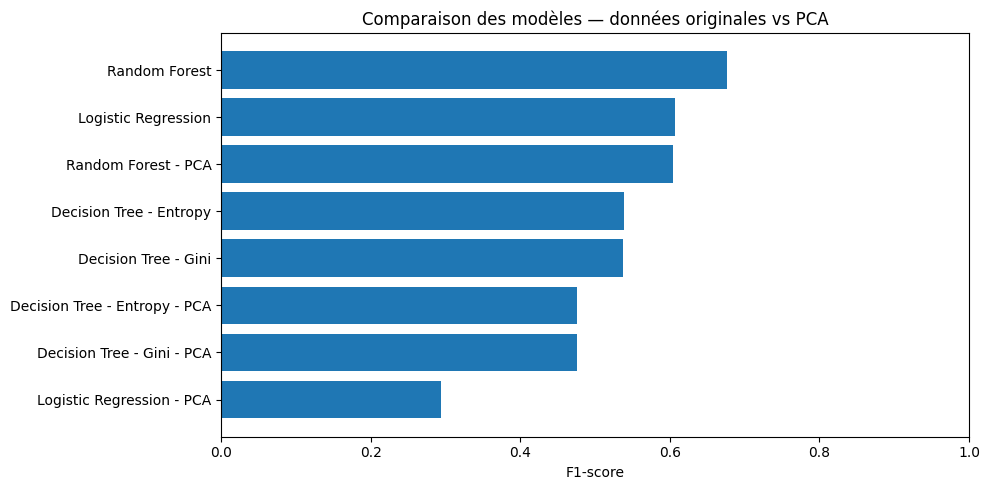

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_data = comparison.sort_values("F1-score")
ax.barh(plot_data["Modèle"], plot_data["F1-score"])
ax.set_xlabel("F1-score")
ax.set_title("Comparaison des modèles — données originales vs PCA")
ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig(FIG_DIR / "pca_model_f1_comparison.png", dpi=150)
plt.show()


### Interprétation

Le graphique confirme visuellement le classement établi en section 2 : le Random Forest sur données originales domine nettement les 7 autres configurations.

### Décision

Ce graphique sera repris dans le rapport final pour illustrer de façon synthétique la hiérarchie des 8 modèles testés.

# 4. Rapports de classification

Le rapport de classification détaille, pour chaque modèle, la Precision, le Recall et le F1-score obtenus séparément sur chacune des deux classes (réservation maintenue / annulée).

In [6]:
for name, y_pred in predictions.items():
    print("=" * 80)
    print(name)
    print(classification_report(y_test, y_pred, target_names=["Non annulée", "Annulée"], zero_division=0))


Logistic Regression
              precision    recall  f1-score   support

 Non annulée       0.84      0.91      0.87     12644
     Annulée       0.69      0.54      0.61      4802

    accuracy                           0.81     17446
   macro avg       0.77      0.72      0.74     17446
weighted avg       0.80      0.81      0.80     17446

Decision Tree - Entropy
              precision    recall  f1-score   support

 Non annulée       0.86      0.63      0.73     12644
     Annulée       0.43      0.73      0.54      4802

    accuracy                           0.66     17446
   macro avg       0.64      0.68      0.63     17446
weighted avg       0.74      0.66      0.67     17446

Decision Tree - Gini
              precision    recall  f1-score   support

 Non annulée       0.86      0.63      0.73     12644
     Annulée       0.43      0.72      0.54      4802

    accuracy                           0.66     17446
   macro avg       0.64      0.68      0.63     17446
weighted 

### Interprétation

Pour le modèle retenu (Random Forest, données originales — détaillé en section 6), la classe « Annulée » obtient un Recall élevé mais une Precision plus modeste, ce qui traduit un choix assumé : détecter un maximum de réservations à risque, quitte à générer quelques fausses alertes. À l'inverse, la Logistic Regression obtient une meilleure Precision mais un Recall plus faible sur cette même classe — elle détecte moins d'annulations réelles, mais se trompe moins souvent quand elle en signale une.

### Décision

Le choix entre Precision et Recall dépend du coût métier de chaque type d'erreur. Dans ce projet, on privilégie le Recall (détecter un maximum d'annulations réelles), car une fausse alerte coûte moins cher à l'hôtel (relance client superflue) qu'une annulation non anticipée (chambre non relouée à temps).

# 5. Matrices de confusion et courbes ROC

Ces deux représentations graphiques complètent les métriques chiffrées en visualisant la répartition des erreurs de chaque modèle.

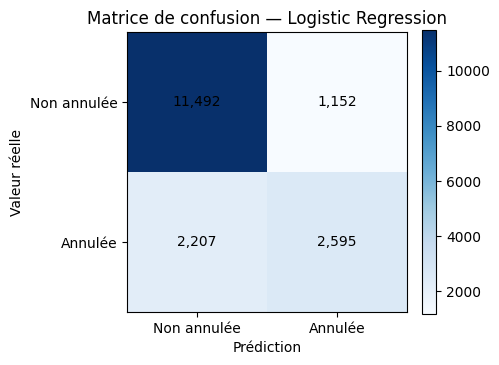

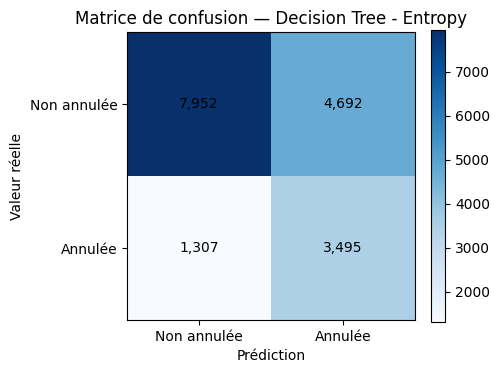

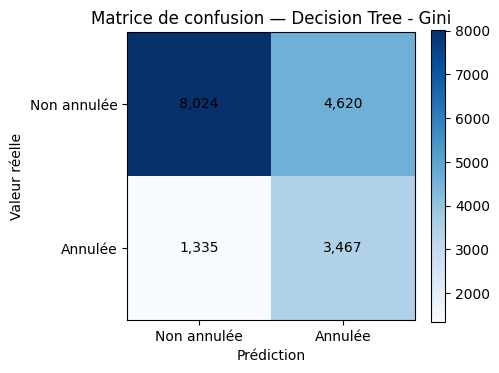

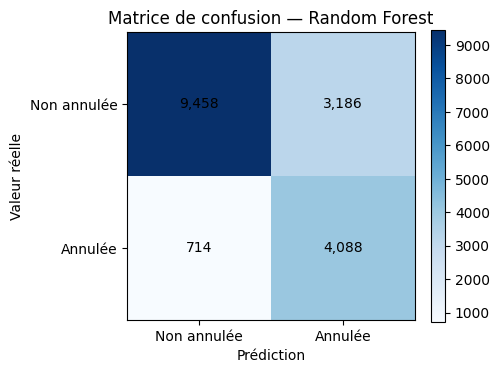

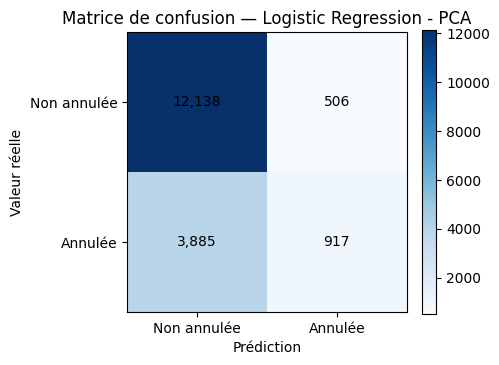

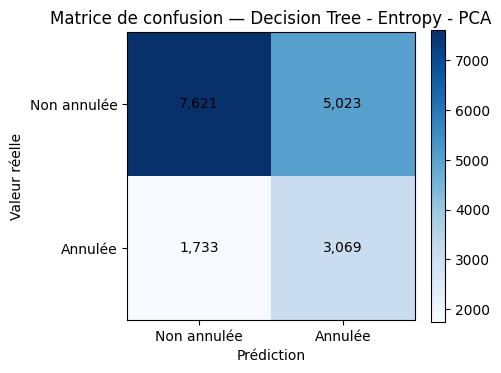

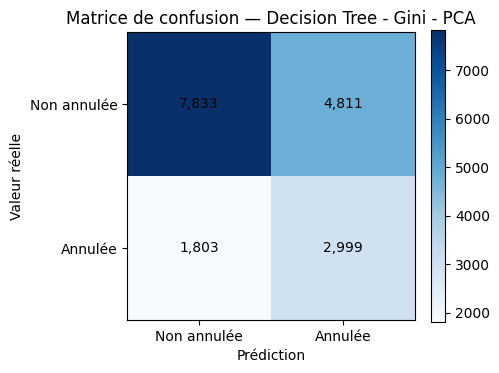

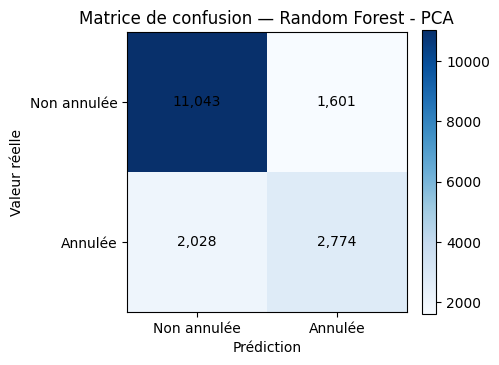

In [7]:
for name, y_pred in predictions.items():
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(4.8, 4))
    im = ax.imshow(cm, cmap="Blues")
    for (i, j), value in np.ndenumerate(cm):
        ax.text(j, i, f"{value:,}", ha="center", va="center")
    ax.set_xticks([0, 1], labels=["Non annulée", "Annulée"])
    ax.set_yticks([0, 1], labels=["Non annulée", "Annulée"])
    ax.set_xlabel("Prédiction")
    ax.set_ylabel("Valeur réelle")
    ax.set_title(f"Matrice de confusion — {name}")
    fig.colorbar(im, ax=ax, fraction=0.046)
    plt.tight_layout()
    safe_name = name.lower().replace(" ", "_").replace("-", "")
    plt.savefig(FIG_DIR / f"confusion_{safe_name}.png", dpi=140)
    plt.show()


### Interprétation

Les matrices de confusion permettent de visualiser directement le nombre de faux positifs et de faux négatifs propre à chaque modèle, complémentaire aux métriques agrégées calculées en section 2.

### Décision

Ces matrices seront conservées dans `reports/figures/` pour appuyer le choix du modèle final auprès de parties prenantes non techniques.

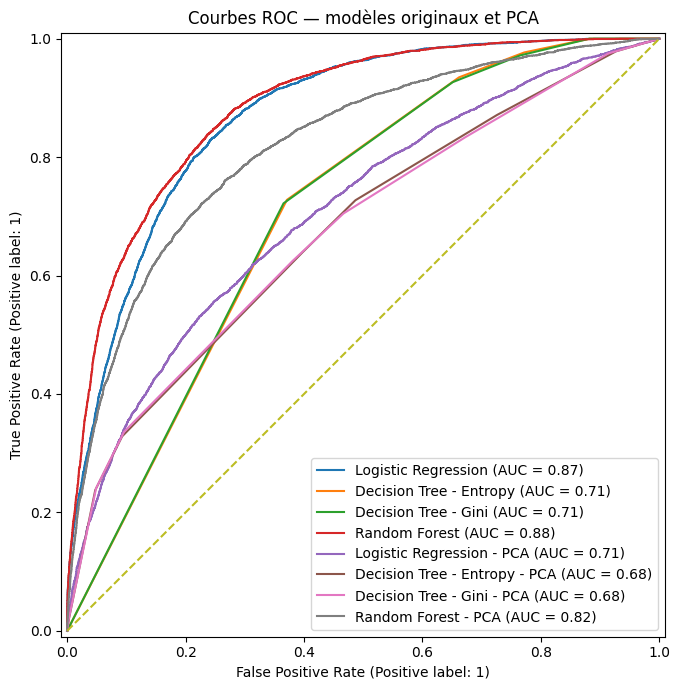

In [8]:
fig, ax = plt.subplots(figsize=(8, 7))
for name, y_proba in probabilities.items():
    RocCurveDisplay.from_predictions(y_test, y_proba, name=name, ax=ax)
ax.plot([0, 1], [0, 1], linestyle="--")
ax.set_title("Courbes ROC — modèles originaux et PCA")
plt.tight_layout()
plt.savefig(FIG_DIR / "roc_curves.png", dpi=150)
plt.show()


### Interprétation

Les courbes ROC confirment la hiérarchie observée avec le ROC-AUC numérique : les modèles Random Forest et Logistic Regression sur données originales dominent visuellement, tandis que les modèles PCA se rapprochent davantage de la diagonale (équivalente à un classement aléatoire), en particulier la Logistic Regression PCA.

### Décision

Cette confirmation visuelle renforce la décision méthodologique de ne pas retenir la PCA pour ce projet (section 6).

# 6. Sélection du modèle final et décision concernant la PCA

In [9]:
best_model = comparison.iloc[0]
print("Modèle retenu :", best_model["Modèle"])
print("Version        :", best_model["Version_données"])
print("F1-score      :", round(best_model["F1-score"], 4))
print("ROC-AUC       :", round(best_model["ROC-AUC"], 4))
best_model.to_frame("Valeur")


Modèle retenu : Random Forest
Version        : Original
F1-score      : 0.677
ROC-AUC       : 0.8831


,Valeur
Modèle,Random Forest
Famille,Random Forest
Version_données,Original
Nombre_variables,556
Temps_entraînement_secondes,2.65263
Temps_inférence_secondes,0.104728
Accuracy,0.776453
Precision,0.562002
Recall,0.851312
F1-score,0.677045


### Interprétation

Le modèle retenu est le **Random Forest entraîné sur les données originales** (556 variables), avec un F1-score de 0,677 et un ROC-AUC de 0,883 — les meilleurs scores obtenus parmi les 8 modèles testés, avec un Recall de 85,1 % sur la classe annulée.

### Décision

Ce modèle est désigné comme modèle final du projet. Il offre le meilleur compromis entre performance globale et capacité à détecter les réservations à risque d'annulation, tout en conservant des variables interprétables pour l'équipe métier de l'hôtel.

In [10]:
best_original = comparison.query("Version_données == 'Original'").iloc[0]
best_pca = comparison.query("Version_données == 'PCA'").iloc[0]

print("Meilleur modèle original :", best_original["Modèle"])
print("Meilleur modèle PCA      :", best_pca["Modèle"])
print(f"Écart F1 (PCA - original) : {best_pca['F1-score'] - best_original['F1-score']:+.4f}")
print(f"Écart ROC-AUC             : {best_pca['ROC-AUC'] - best_original['ROC-AUC']:+.4f}")

pca_retained = (
    best_pca["F1-score"] >= best_original["F1-score"] - 0.01
    and best_pca["ROC-AUC"] >= best_original["ROC-AUC"] - 0.01
)
print("Décision PCA :", "Retenue" if pca_retained else "Testée mais non retenue pour le modèle final")


Meilleur modèle original : Random Forest
Meilleur modèle PCA      : Random Forest - PCA
Écart F1 (PCA - original) : -0.0725
Écart ROC-AUC             : -0.0641
Décision PCA : Testée mais non retenue pour le modèle final


### Interprétation

Même en comparant les meilleurs représentants de chaque version, l'écart reste défavorable à la PCA : -0,0725 en F1-score et -0,0641 en ROC-AUC par rapport à la version originale. Cet écart dépasse la marge de tolérance fixée (1 point de pourcentage), ce qui déclenche automatiquement la conclusion « Testée mais non retenue pour le modèle final ».

### Décision

La réduction de dimension par PCA est documentée comme une piste explorée et rejetée pour ce projet : la compression à 9 composantes (98,4 % de réduction) ne compense pas la perte de performance constatée, ni la perte totale d'interprétation métier des variables. Le pipeline final retenu utilise donc les 556 variables originales, sans étape de PCA.

# 7. Importance des variables du modèle retenu

Les composantes PCA n'ayant pas d'interprétation métier directe, l'importance des variables est calculée uniquement pour le Random Forest entraîné sur les données originales, afin de rester interprétable pour l'équipe métier.

In [11]:
feature_names = json.loads((PROCESSED_DIR / "feature_names.json").read_text(encoding="utf-8"))
rf = loaded_models["Random Forest"]
importance = pd.DataFrame({
    "Variable": feature_names,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False).head(20)
importance


,Variable,Importance
0,num__lead_time,0.111690
164,cat__country_PRT,0.101642
15,num__required_car_parking_spaces,0.080922
543,cat__agent_9.0,0.049238
16,num__total_of_special_requests,0.045188
14,num__adr,0.044505
554,cat__customer_type_Transient,0.036422
210,cat__market_segment_Online TA,0.034190
209,cat__market_segment_Offline TA/TO,0.028948
233,cat__deposit_type_Non Refund,0.025797


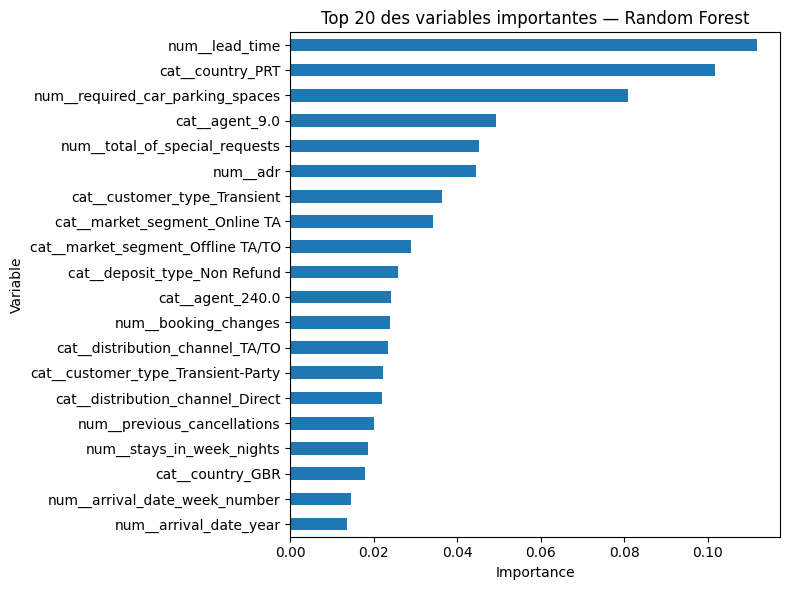

In [12]:
ax = importance.sort_values("Importance").plot(
    x="Variable", y="Importance", kind="barh", legend=False,
    figsize=(8, 6), title="Top 20 des variables importantes — Random Forest"
)
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig(FIG_DIR / "feature_importance_random_forest.png", dpi=150)
plt.show()


### Interprétation

Les variables les plus déterminantes sont, dans l'ordre : `lead_time` (délai de réservation, importance 0,112), `country = PRT` (Portugal, 0,102), le nombre de places de parking demandées (0,081), l'identifiant d'agence 9 (0,049), le nombre de demandes spéciales (0,045) et le tarif journalier moyen `adr` (0,045). Ces résultats corroborent les corrélations et tendances déjà observées dans l'EDA (Notebook 02, sections 3.1 et 6) : `lead_time` était déjà la variable la plus corrélée à l'annulation, et `total_of_special_requests` faisait partie des variables jugées à surveiller.

### Décision

Ces variables constituent les leviers d'action les plus pertinents à communiquer à l'équipe métier de l'hôtel : surveiller particulièrement les réservations à long délai, ajuster la politique commerciale sur le marché portugais, et considérer le nombre de demandes spéciales comme un signal positif d'engagement du client.

# 8. Conclusion

L'évaluation des 8 modèles entraînés dans le Notebook 04 permet de conclure que le **Random Forest entraîné sur les données originales** (556 variables) constitue le modèle final le plus adapté à l'objectif métier de ce projet, avec un F1-score de 0,677 et un ROC-AUC de 0,883 sur la classe « annulée ».

La réduction de dimension par PCA, bien qu'ayant atteint son objectif technique (95 % de variance conservée avec 98,4 % de réduction dimensionnelle), a été testée puis écartée : elle dégrade systématiquement la performance des 4 familles de modèles comparées, sans exception, tout en supprimant l'interprétation métier des variables.

L'analyse de l'importance des variables confirme la cohérence entre les signaux identifiés dès l'EDA (`lead_time`, `total_of_special_requests`) et les facteurs réellement exploités par le modèle final, ce qui renforce la confiance dans la validité du pipeline mis en œuvre sur l'ensemble des cinq notebooks du projet.
